# AI Loan Decision Support System
## Model Development & Classification

Notebook ini difokuskan untuk melatih algoritma Machine Learning dalam mendeteksi risiko gagal bayar (kredit macet) berdasarkan profil finansial peminjam. 

**Project:** BijakPinjam  
**Tim:** PJK-GM032

**Tahapan Utama:**
1. Import Library & Load Dataset (Dataset hasil *logic generation*).
2. Pemisahan Fitur (X) dan Target (y).
3. Evaluasi Baseline Model (Random Forest).
4. Analisis Feature Importance.
5. Pelatihan Model Final (XGBoost Classifier).
6. Ekspor Model Terbaik (.pkl).

In [1]:
# Import Library Utama
import pandas as pd
import numpy as np

# Import Library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import Library Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Import Library Ekspor
import joblib

print("Library berhasil diimport dengan sempurna!")

Library berhasil diimport dengan sempurna!


## 1. Load Dataset Hasil Preprocessing
Mengimpor dataset berukuran 600.000 baris yang sebelumnya sudah dibersihkan, di-encode, dan diskalakan (*Standardization*). Dataset ini memiliki probabilitas *kredit macet* yang logis berdasarkan rasio DTI (*Debt-to-Income*).

In [2]:
# Pastikan file excel berada di folder yang sama dengan notebook ini
path = "Dataset_Bersih_Siap_ML_600k.xlsx"

print("Sedang memuat dataset...")
df = pd.read_excel(path)

print("Dataset berhasil dimuat!")
df.head()

Sedang memuat dataset...
Dataset berhasil dimuat!


,pendapatan_tahunan,total_utang_saat_ini,jumlah_pinjaman_diajukan,tenor_bulan,bunga_tahunan,monthly_installment,debt_to_income_ratio,remaining_income,status_pekerjaan_encoded,status_kredit_encoded
0,-0.574467,-0.540563,-1.523670,12,0.170028,-0.763543,-0.557759,-0.099993,0,0
1,0.867735,-1.482126,0.465834,60,0.097830,-0.469867,-0.844619,1.205769,0,0
2,1.433833,0.214905,0.095698,12,0.198129,1.507809,-0.138506,0.597773,2,0
3,1.275551,-1.131559,0.169649,24,0.151637,0.285538,-0.612668,1.190766,3,0
4,0.983943,0.786168,-1.001611,36,0.170698,-0.759678,-0.676947,1.076905,2,0


## 2. Menentukan Feature (X) dan Target (y)
Kita akan memisahkan kolom target yang ingin diprediksi (`status_kredit_encoded`) dari kolom-kolom lain yang bertindak sebagai prediktor (fitur). Setelah itu, data dibagi menjadi 80% untuk pelatihan (*training*) dan 20% untuk pengujian (*testing*).

In [3]:
# Menentukan target
target = "status_kredit_encoded"

# X adalah semua kolom KECUALI target, y adalah targetnya
X = df.drop(columns=[target])
y = df[target]

print(f"Jumlah Feature (X) yang digunakan: {X.shape[1]} fitur")

# Train Test Split (80% Training, 20% Testing) dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensi Data Training :", X_train.shape)
print("Dimensi Data Testing  :", X_test.shape)

Jumlah Feature (X) yang digunakan: 9 fitur
Dimensi Data Training : (480000, 9)
Dimensi Data Testing  : (120000, 9)


## 3. Pelatihan Baseline Model: Random Forest
Kita melatih algoritma **Random Forest** sebagai model dasar (*baseline*) untuk melihat seberapa baik fitur finansial kita membedakan nasabah lancar dan berisiko.

Sedang melatih model Random Forest...

=== EVALUASI RANDOM FOREST (BASELINE) ===
Accuracy: 0.7976

              precision    recall  f1-score   support

           0       0.84      0.82      0.83     72463
           1       0.73      0.77      0.75     47537

    accuracy                           0.80    120000
   macro avg       0.79      0.79      0.79    120000
weighted avg       0.80      0.80      0.80    120000



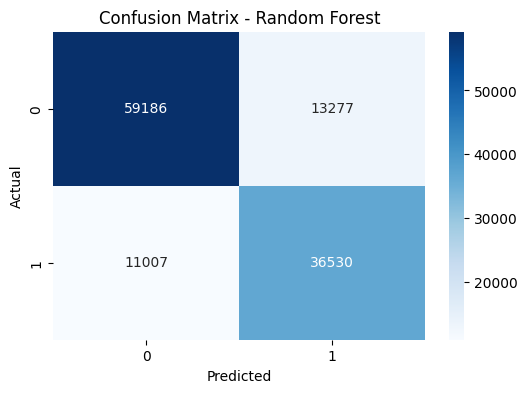

In [4]:
print("Sedang melatih model Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Prediksi Data Testing
y_pred_rf = rf_model.predict(X_test)

print("\n=== EVALUASI RANDOM FOREST (BASELINE) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 4. Feature Importance
Menganalisis dan memvisualisasikan fitur mana yang paling diandalkan oleh model dalam menentukan keputusan kredit. Hal ini penting untuk memastikan model mengambil keputusan berdasarkan logika bisnis yang benar (misalnya: cicilan bulanan atau beban utang), bukan karena anomali data.

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_12512\4014049984.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")


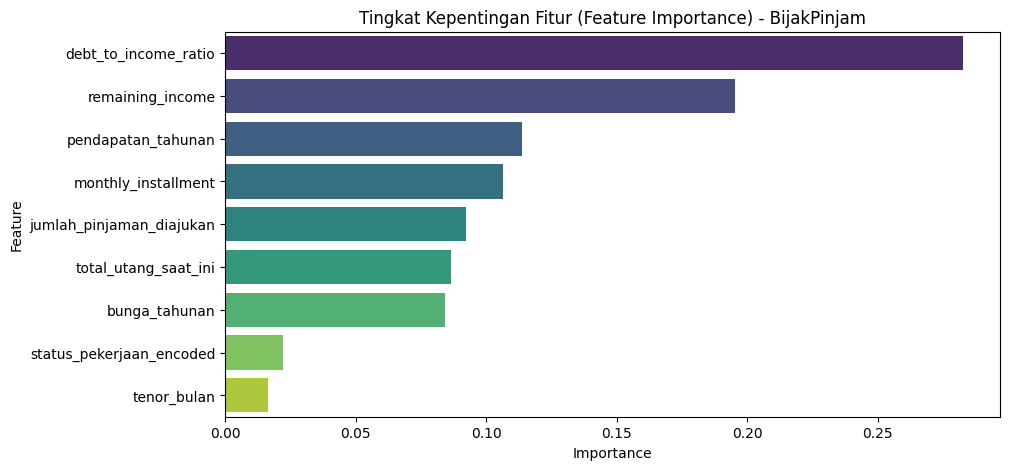

,Feature,Importance
6,debt_to_income_ratio,0.282801
7,remaining_income,0.195424
0,pendapatan_tahunan,0.113732
5,monthly_installment,0.106403
2,jumlah_pinjaman_diajukan,0.092093
1,total_utang_saat_ini,0.086467
4,bunga_tahunan,0.084386
8,status_pekerjaan_encoded,0.022311
3,tenor_bulan,0.016384


In [5]:
# Mengekstrak Feature Importance dari Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Menampilkan grafik Feature Importance
plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Tingkat Kepentingan Fitur (Feature Importance) - BijakPinjam")
plt.show()

feature_importance.head(10)

## 5. Pelatihan Model Final: XGBoost Classifier
Meski Random Forest sudah memberikan hasil yang baik berkat dataset logis yang baru, kita mengoptimalkan performa menggunakan algoritma *Boosting*, yaitu **XGBoost**. Algoritma ini membangun pohon keputusan secara bertahap untuk mengoreksi kesalahan prediksi dari pohon sebelumnya, menjadikannya sangat tangguh untuk mendeteksi pelanggan berisiko.

Sedang melatih model XGBoost Classifier...

=== EVALUASI XGBOOST (MODEL FINAL) ===
Accuracy: 0.8031

              precision    recall  f1-score   support

           0       0.84      0.83      0.84     72463
           1       0.74      0.77      0.75     47537

    accuracy                           0.80    120000
   macro avg       0.79      0.80      0.80    120000
weighted avg       0.80      0.80      0.80    120000



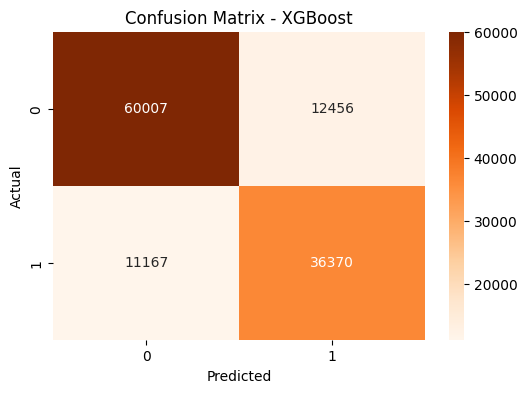

In [6]:
# Menghitung rasio kelas untuk parameter scale_pos_weight
# Berdasarkan EDA kita: Lancar ~60%, Macet ~40%. Rasio: 60/40 = 1.5
ratio_weight = 1.5

# Inisialisasi model XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=ratio_weight,
    n_estimators=150,
    max_depth=6,            
    learning_rate=0.1,      
    random_state=42,
    eval_metric='logloss',  
    n_jobs=-1
)

print("Sedang melatih model XGBoost Classifier...")
xgb_model.fit(X_train, y_train)

# Prediksi menggunakan data testing
y_pred_xgb = xgb_model.predict(X_test)

print("\n=== EVALUASI XGBOOST (MODEL FINAL) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print(classification_report(y_test, y_pred_xgb))

# Visualisasi Confusion Matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 6. Menyimpan Model Terbaik untuk Integrasi Aplikasi
Model XGBoost telah dilatih dan menunjukkan performa yang optimal serta stabil dalam mendeteksi risiko kredit. Langkah terakhir adalah mengekspor model ini ke dalam file berformat `.pkl`. File ini akan digunakan langsung oleh *backend* aplikasi Streamlit BijakPinjam untuk melakukan prediksi secara *real-time*.

In [7]:
# Nama file model final
model_final_filename = 'model_risiko_pinjaman_xgb.pkl'

# Menyimpan model menggunakan joblib
joblib.dump(xgb_model, model_final_filename)

print(f"✅ Sukses! Model Machine Learning final berhasil disimpan dengan nama: {model_final_filename}")
print("Model siap diintegrasikan ke aplikasi Streamlit!")

✅ Sukses! Model Machine Learning final berhasil disimpan dengan nama: model_risiko_pinjaman_xgb.pkl
Model siap diintegrasikan ke aplikasi Streamlit!
